In [2]:
import pandas as pd

origin_df = pd.read_csv('/home/work/hocheol_dir/workspace/data/045_data/new_origin_data_annot.csv')
origin_df.head()

,filename,right_cheek,left_cheek,path
0,F0001_IND_GM_75_0_01.JPG,3.0,3.0,045.new_origin_data/0001/F0001_IND_GM_75_0_01.JPG
1,F0001_IND_GM_75_0_02.JPG,3.0,3.0,045.new_origin_data/0001/F0001_IND_GM_75_0_02.JPG
2,F0001_IND_GM_75_0_03.JPG,3.0,3.0,045.new_origin_data/0001/F0001_IND_GM_75_0_03.JPG
3,F0001_IND_GM_75_0_04.JPG,3.0,3.0,045.new_origin_data/0001/F0001_IND_GM_75_0_04.JPG
4,F0001_IND_GM_75_0_05.JPG,3.0,3.0,045.new_origin_data/0001/F0001_IND_GM_75_0_05.JPG


In [2]:
# 가족끼리 같은 아이디 쓰는데 묶어서 train test split?
# 새 id : id_relation

new_json_dict = {}

for idx, row in origin_df.iterrows():
    # print(idx)
    # print(len(row))
    # print(row.values)
    filename, left, right, path = row.values

    id = filename.split('_')[0]
    relation = filename.split('_')[2]
    angle = filename.split('_')[4]
    photo_num = filename.split('_')[-1].split('.')[0]
    
    new_id = f"{id}_{relation}"

    if new_id not in new_json_dict.keys():
        new_json_dict[new_id] = {
            'id': new_id,
            'data':[]
        }
    
    new_json_dict[new_id]['data'].append({'photo_num':photo_num, 'path':path, 'left':left, 'right':right, 'angle':angle})

    # print(id, relation, left, right, angle, photo_num, new_id, path)

In [10]:
len(origin_df)

4264

In [11]:
len(new_json_dict.keys())

328

In [12]:
i = 0
for key, value in new_json_dict.items():
    print(key, value['id'])
    print(value)
    for element in value['data']:
        print(element)
        i+=1
        
    break
i

F0001_GM F0001_GM
{'id': 'F0001_GM', 'data': [{'photo_num': '01', 'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_01.JPG', 'left': 3.0, 'right': 3.0, 'angle': '0'}, {'photo_num': '02', 'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_02.JPG', 'left': 3.0, 'right': 3.0, 'angle': '0'}, {'photo_num': '03', 'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_03.JPG', 'left': 3.0, 'right': 3.0, 'angle': '0'}, {'photo_num': '04', 'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_04.JPG', 'left': 3.0, 'right': 3.0, 'angle': '0'}, {'photo_num': '05', 'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_05.JPG', 'left': 3.0, 'right': 3.0, 'angle': '0'}, {'photo_num': '01', 'path': '045.new_origin_data/0001/F0001_IND_GM_75_45_01.JPG', 'left': 3.0, 'right': 3.0, 'angle': '45'}, {'photo_num': '01', 'path': '045.new_origin_data/0001/F0001_IND_GM_75_-45_01.JPG', 'left': 3.0, 'right': 3.0, 'angle': '-45'}, {'photo_num': '02', 'path': '045.new_origin_data/0001/F0001_IND_GM_75_45_02.JPG', 'left

13

In [13]:
new_json = [value for key, value in new_json_dict.items()]
len(new_json)

328

In [14]:
import json
with open("/home/work/hocheol_dir/workspace/data/045_data/new_origin_data_annot.json", 'w') as f:
    json.dump(new_json, f, indent=2, ensure_ascii=False)

In [ ]:
################################### 1차로 json 파일 만듦

In [45]:
# 정면 사진(angle 0도)를 가지고 양쪽 볼 crop
# 폴더명: id_relation

In [3]:
import os
import json
import cv2

root_dir = "/home/work/hocheol_dir/workspace/data/045_data/045.F_crop"
with open("/home/work/hocheol_dir/workspace/data/045_data/new_origin_data_annot.json", 'r') as f:
    json_data = json.load(f)
json_data[0]

{'id': 'F0001_GM',
 'data': [{'photo_num': '01',
   'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_01.JPG',
   'left': 3.0,
   'right': 3.0,
   'angle': '0'},
  {'photo_num': '02',
   'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_02.JPG',
   'left': 3.0,
   'right': 3.0,
   'angle': '0'},
  {'photo_num': '03',
   'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_03.JPG',
   'left': 3.0,
   'right': 3.0,
   'angle': '0'},
  {'photo_num': '04',
   'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_04.JPG',
   'left': 3.0,
   'right': 3.0,
   'angle': '0'},
  {'photo_num': '05',
   'path': '045.new_origin_data/0001/F0001_IND_GM_75_0_05.JPG',
   'left': 3.0,
   'right': 3.0,
   'angle': '0'},
  {'photo_num': '01',
   'path': '045.new_origin_data/0001/F0001_IND_GM_75_45_01.JPG',
   'left': 3.0,
   'right': 3.0,
   'angle': '45'},
  {'photo_num': '01',
   'path': '045.new_origin_data/0001/F0001_IND_GM_75_-45_01.JPG',
   'left': 3.0,
   'right': 3.0,
   'angle': '-45'},
  {'phot

2025-05-15 20:41:48.648439: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 20:41:48.705336: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-15 20:41:48.705386: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-15 20:41:48.706927: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-15 20:41:48.717903: I tensorflow/core/platform/cpu_feature_guar

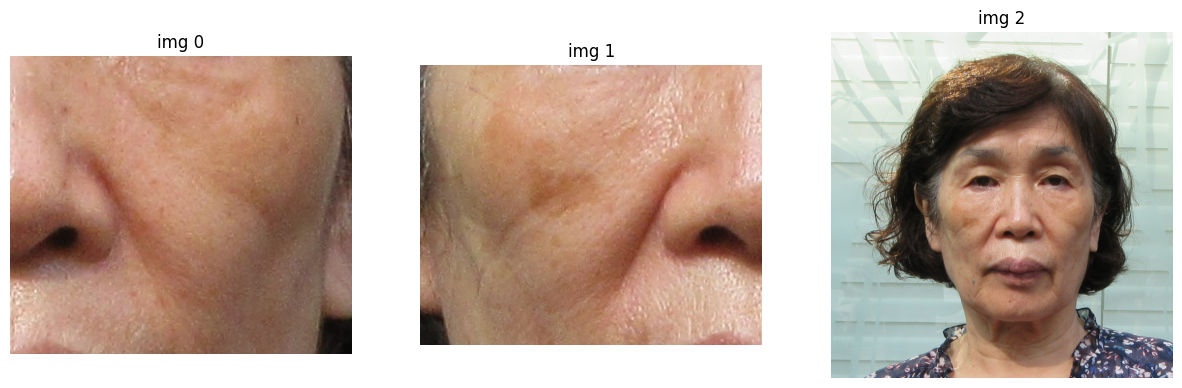

In [4]:
from crop_data import crop_cheeks_from_image
import matplotlib.pyplot as plt
import cv2

img_path = '/home/work/hocheol_dir/workspace/data/045_data/045.new_origin_data/0001/F0001_IND_GM_75_0_01.JPG'
left_cheek, right_cheek = crop_cheeks_from_image(img_path)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(left_cheek)
ax[1].imshow(right_cheek)
ax[2].imshow(img)
for i in range(3):
    ax[i].axis('off')
    ax[i].set_title(f"img {i}")
plt.show()

In [ ]:
import os
from tmp.crop_data import crop_cheeks_from_image

# 새 id : id_relation_photo#

new_json = []
root_dir = "/home/work/hocheol_dir/workspace/data/045_data"

for element in json_data:
    # print(element)
    os.makedirs(os.path.join(root_dir, '045.F_crop', element['id']), exist_ok=True)
    for data in element['data']:
        if data['angle'] == '0':
            # print(data)
            new_id = f"{element['id']}_{data['photo_num']}"
            new_path = os.path.join(root_dir, '045.F_crop', element['id'], f"{element['id']}_{data['photo_num']}")

            left_cheek_path = os.path.join('045.F_crop', element['id'], f"left_cheek_{new_id}.jpg")
            right_cheek_path = os.path.join('045.F_crop', element['id'], f"right_cheek_{new_id}.jpg")
            
            left_cheek, right_cheek = crop_cheeks_from_image(os.path.join(root_dir, data['path']))
            cv2.imwrite(os.path.join(root_dir, left_cheek_path), left_cheek)
            cv2.imwrite(os.path.join(root_dir, right_cheek_path), right_cheek)

            new_data = {
                'id': new_id,
                'left_cheek_path': left_cheek_path,
                'right_cheek_path': right_cheek_path,
                'left_label': data['left'],
                'right_label': data['right'],
            }
            new_json.append(new_data)
    # break
with open('/home/work/hocheol_dir/workspace/data/045_data/045.F_crop.json', 'w') as f:
    json.dump(new_json, f, indent=2, ensure_ascii=False)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1747310448.543132 2449906 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747310448.563507 2449907 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747310448.568484 2449910 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
W0000 00:00:1747310448.625977 2449920 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747310448.646630 2449920 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:

In [ ]:
################################## 총 4264개 이미지 중 정면 사진 '*_0_*'=0도의 개수 1635개, 양쪽 볼 crop하니 3270개

In [1]:
############################### forehead 필요해!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [23]:
import os
import json
import cv2

root_dir = "/home/work/hocheol_dir/workspace/data/045_data"
with open("/home/work/hocheol_dir/workspace/data/045_data/045.F_crop.json", 'r') as f:
    json_data = json.load(f)
json_data[0]

{'id': 'F0001_GM_01',
 'left_cheek_path': '045.F_crop/F0001_GM/left_cheek_F0001_GM_01.jpg',
 'right_cheek_path': '045.F_crop/F0001_GM/right_cheek_F0001_GM_01.jpg',
 'left_label': 3.0,
 'right_label': 3.0}

In [ ]:
import os
from tmp.crop_data import crop_cheeks_and_forehead_from_image

new_json = []

for element in json_data:
    # print(element)
    os.makedirs(os.path.join(root_dir, '045.F_crop', element['id']), exist_ok=True)
    for data in element['data']:
        if data['angle'] == '0':
            # print(data)
            new_id = f"{element['id']}_{data['photo_num']}"
            new_path = os.path.join(root_dir, '045.F_crop', element['id'], f"{element['id']}_{data['photo_num']}")

            # left_cheek_path = os.path.join('045.F_crop', element['id'], f"left_cheek_{new_id}.jpg")
            # right_cheek_path = os.path.join('045.F_crop', element['id'], f"right_cheek_{new_id}.jpg")
            forehead_path = os.path.join('045.F_crop', element['id'], f"forehead_{new_id}.jpg")
            
            # forehead, left_cheek, right_cheek = crop_cheeks_and_forehead_from_image(os.path.join(root_dir, data['path']))
            # cv2.imwrite(os.path.join(root_dir, left_cheek_path), left_cheek)
            # cv2.imwrite(os.path.join(root_dir, right_cheek_path), right_cheek)
            # cv2.imwrite(os.path.join(root_dir, forehead_path), forehead)

            new_data = {
                'id': new_id,
            #     'left_cheek_path': left_cheek_path,
            #     'right_cheek_path': right_cheek_path,
            #     'left_label': data['left'],
            #     'right_label': data['right'],
                'forehead_path': forehead_path
            }
            new_json.append(new_data)
    # break
# with open('/home/work/hocheol_dir/workspace/data/045_data/045.F_crop.json', 'w') as f:
#     json.dump(new_json, f, indent=2, ensure_ascii=False)

In [24]:
# new_json_df에는 forehead_path만 있음 -> origin_json_df에 merge
import pandas as pd
new_json_df = pd.DataFrame(new_json)
origin_json_df = pd.DataFrame(json_data)

In [26]:
origin_json_df

,id,left_cheek_path,right_cheek_path,left_label,right_label
0,F0001_GM_01,045.F_crop/F0001_GM/left_cheek_F0001_GM_01.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_01.jpg,3.0,3.0
1,F0001_GM_02,045.F_crop/F0001_GM/left_cheek_F0001_GM_02.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_02.jpg,3.0,3.0
2,F0001_GM_03,045.F_crop/F0001_GM/left_cheek_F0001_GM_03.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_03.jpg,3.0,3.0
3,F0001_GM_04,045.F_crop/F0001_GM/left_cheek_F0001_GM_04.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_04.jpg,3.0,3.0
4,F0001_GM_05,045.F_crop/F0001_GM/left_cheek_F0001_GM_05.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_05.jpg,3.0,3.0
...,...,...,...,...,...
1630,F0299_M_01,045.F_crop/F0299_M/left_cheek_F0299_M_01.jpg,045.F_crop/F0299_M/right_cheek_F0299_M_01.jpg,NaN,NaN
1631,F0299_M_02,045.F_crop/F0299_M/left_cheek_F0299_M_02.jpg,045.F_crop/F0299_M/right_cheek_F0299_M_02.jpg,NaN,NaN
1632,F0299_M_03,045.F_crop/F0299_M/left_cheek_F0299_M_03.jpg,045.F_crop/F0299_M/right_cheek_F0299_M_03.jpg,NaN,NaN
1633,F0299_M_04,045.F_crop/F0299_M/left_cheek_F0299_M_04.jpg,045.F_crop/F0299_M/right_cheek_F0299_M_04.jpg,NaN,NaN


In [37]:
# pd.merge(origin_json_df, new_json_df, how='outer', on='id').to_json('/home/work/hocheol_dir/workspace/data/045_data/045.F_crop_with_forehead.json', orient='records', force_ascii=False, indent=2)
with open('/home/work/hocheol_dir/workspace/data/045_data/045.F_crop_with_forehead.json', 'w') as f:
    json.dump(pd.merge(origin_json_df, new_json_df, how='outer', on='id').to_dict(orient='records'), f, indent=2, ensure_ascii=False)

In [38]:
# 나이 넣어야함

In [ ]:
merged_df = pd.merge(origin_json_df, new_json_df, how='outer', on='id')
merged_df['age'] = -1
merged_df.head()

,id,left_cheek_path,right_cheek_path,left_label,right_label,forehead_path,age
0,F0001_GM_01,045.F_crop/F0001_GM/left_cheek_F0001_GM_01.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_01.jpg,3.0,3.0,045.F_crop/F0001_GM/forehead_F0001_GM_01.jpg,-1
1,F0001_GM_02,045.F_crop/F0001_GM/left_cheek_F0001_GM_02.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_02.jpg,3.0,3.0,045.F_crop/F0001_GM/forehead_F0001_GM_02.jpg,-1
2,F0001_GM_03,045.F_crop/F0001_GM/left_cheek_F0001_GM_03.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_03.jpg,3.0,3.0,045.F_crop/F0001_GM/forehead_F0001_GM_03.jpg,-1
3,F0001_GM_04,045.F_crop/F0001_GM/left_cheek_F0001_GM_04.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_04.jpg,3.0,3.0,045.F_crop/F0001_GM/forehead_F0001_GM_04.jpg,-1
4,F0001_GM_05,045.F_crop/F0001_GM/left_cheek_F0001_GM_05.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_05.jpg,3.0,3.0,045.F_crop/F0001_GM/forehead_F0001_GM_05.jpg,-1


In [56]:
import random
origin_path = '/home/work/hocheol_dir/workspace/data/045_data/045.new_origin_data'

# age 채우기 함수
def fill_age(row):
    id_part = row['id'].split('_')[0]  # F0001
    relation_part = row['id'].split('_')[1]
    folder_name = id_part[1:]  # 0001
    target_dir = os.path.join(origin_path, folder_name)
    
    if not os.path.exists(target_dir):
        print(f"경고: {target_dir} 디렉토리가 없습니다.")
        return -1
    
    # 조건에 맞는 파일 찾기
    candidate_files = [f for f in os.listdir(target_dir) if id_part in f and f'_{relation_part}_' in f]
    if not candidate_files:
        print(f"경고: {target_dir} 디렉토리에 조건에 맞는 파일이 없습니다.")
        return -1
    

    selected_file = random.choice(candidate_files)
    # print(selected_file)
    age_value = selected_file.split('_')[-3]
    
    return int(age_value)

# 적용
merged_df['age'] = merged_df.apply(fill_age, axis=1)
merged_df.sample(10).sort_index()

,id,left_cheek_path,right_cheek_path,left_label,right_label,forehead_path,age
255,F0043_M_01,045.F_crop/F0043_M/left_cheek_F0043_M_01.jpg,045.F_crop/F0043_M/right_cheek_F0043_M_01.jpg,NaN,NaN,045.F_crop/F0043_M/forehead_F0043_M_01.jpg,43
324,F0050_GF_05,045.F_crop/F0050_GF/left_cheek_F0050_GF_05.jpg,045.F_crop/F0050_GF/right_cheek_F0050_GF_05.jpg,NaN,NaN,045.F_crop/F0050_GF/forehead_F0050_GF_05.jpg,76
480,F0070_GM_01,045.F_crop/F0070_GM/left_cheek_F0070_GM_01.jpg,045.F_crop/F0070_GM/right_cheek_F0070_GM_01.jpg,NaN,NaN,045.F_crop/F0070_GM/forehead_F0070_GM_01.jpg,78
481,F0070_GM_02,045.F_crop/F0070_GM/left_cheek_F0070_GM_02.jpg,045.F_crop/F0070_GM/right_cheek_F0070_GM_02.jpg,NaN,NaN,045.F_crop/F0070_GM/forehead_F0070_GM_02.jpg,78
729,F0110_F_05,045.F_crop/F0110_F/left_cheek_F0110_F_05.jpg,045.F_crop/F0110_F/right_cheek_F0110_F_05.jpg,NaN,NaN,045.F_crop/F0110_F/forehead_F0110_F_05.jpg,49
818,F0127_GM_04,045.F_crop/F0127_GM/left_cheek_F0127_GM_04.jpg,045.F_crop/F0127_GM/right_cheek_F0127_GM_04.jpg,NaN,NaN,045.F_crop/F0127_GM/forehead_F0127_GM_04.jpg,80
823,F0127_M_04,045.F_crop/F0127_M/left_cheek_F0127_M_04.jpg,045.F_crop/F0127_M/right_cheek_F0127_M_04.jpg,NaN,NaN,045.F_crop/F0127_M/forehead_F0127_M_04.jpg,50
1083,F0171_F_04,045.F_crop/F0171_F/left_cheek_F0171_F_04.jpg,045.F_crop/F0171_F/right_cheek_F0171_F_04.jpg,NaN,NaN,045.F_crop/F0171_F/forehead_F0171_F_04.jpg,54
1449,F0263_F_05,045.F_crop/F0263_F/left_cheek_F0263_F_05.jpg,045.F_crop/F0263_F/right_cheek_F0263_F_05.jpg,NaN,NaN,045.F_crop/F0263_F/forehead_F0263_F_05.jpg,44
1484,F0270_M_05,045.F_crop/F0270_M/left_cheek_F0270_M_05.jpg,045.F_crop/F0270_M/right_cheek_F0270_M_05.jpg,NaN,NaN,045.F_crop/F0270_M/forehead_F0270_M_05.jpg,52


In [57]:
with open('/home/work/hocheol_dir/workspace/data/045_data/045.F_crop_with_forehead.json', 'w') as f:
    json.dump(merged_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

In [2]:
# label : 좌우 평균 반올림
# train, val, test split
import pandas as pd
import json
import os
from sklearn.model_selection import train_test_split

with open('/home/work/hocheol_dir/workspace/data/045_data/045.F_crop_with_forehead.json', 'r') as f:
    json_df = pd.DataFrame(json.load(f))

In [ ]:
# label 없애니까 양이 너무 적다.
tmp_df = json_df.copy()
tmp_df.dropna(subset=['left_label', 'right_label'], inplace=True)
tmp_df['label'] = ((tmp_df['left_label'] + tmp_df['right_label']) / 2).round().astype(int)
tmp_df['user_id'] = tmp_df['id'].apply(lambda x: x.split('_')[0])
tmp_df.loc[:, ['user_id', 'label']].drop_duplicates().reset_index(drop=True)

,user_id,label
0,F0001,3
1,F0001,1
2,F0003,2
3,F0005,0
4,F0005,2
5,F0007,0
6,F0007,2
7,F0008,0
8,F0008,2
9,F0009,2


In [38]:
# label(pigment class) 온몸 비틀기!!!!
# label을 양쪽의 평균 반올림하고 Nan은 Dataloader에서 빼는거로 하자
import pandas as pd
import json
with open('/home/work/hocheol_dir/workspace/data/045_data/045.F_crop_with_forehead.json', 'r') as f:
    json_df = pd.DataFrame(json.load(f))

In [39]:
type(json_df[json_df['left_label'].isna()]['left_label'].values[0])

numpy.float64

In [40]:
import numpy as np
def get_label(row):
    if pd.isna(row['left_label']) or pd.isna(row['right_label']):
        return 6
    else:
        return int(round((row['left_label'] + row['right_label']) / 2))

json_df['label'] = json_df.apply(get_label, axis=1).astype(int)

In [74]:
from sklearn.model_selection import GroupShuffleSplit

json_df['group_id'] = json_df['id'].str.extract(r'(F\d+_[A-Z]+)')

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(json_df, groups=json_df['group_id']))

temp_df = json_df.iloc[train_idx].sort_values(by=['id']).reset_index(drop=True)
test_df = json_df.iloc[test_idx].sort_values(by=['id']).reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(gss2.split(temp_df, groups=temp_df['group_id']))

train_df = json_df.iloc[train_idx].sort_values(by=['id']).reset_index(drop=True)
val_df = json_df.iloc[val_idx].sort_values(by=['id']).reset_index(drop=True)

In [76]:
root_dir = '/home/work/hocheol_dir/workspace/data'

train_df['new_left_cheek_path'] = train_df['left_cheek_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Training'))
train_df['new_right_cheek_path'] = train_df['right_cheek_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Training'))
train_df['new_forehead_path'] = train_df['forehead_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Training'))

val_df['new_left_cheek_path'] = val_df['left_cheek_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Validation'))
val_df['new_right_cheek_path'] = val_df['right_cheek_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Validation'))
val_df['new_forehead_path'] = val_df['forehead_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Validation'))

test_df['new_left_cheek_path'] = test_df['left_cheek_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Test'))
test_df['new_right_cheek_path'] = test_df['right_cheek_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Test'))
test_df['new_forehead_path'] = test_df['forehead_path'].apply(lambda x:x.replace('045.F_crop', '045_data/Test'))

In [77]:
train_df.head(1)

,id,left_cheek_path,right_cheek_path,left_label,right_label,forehead_path,age,label,group_id,new_left_cheek_path,new_right_cheek_path,new_forehead_path
0,F0001_GM_01,045.F_crop/F0001_GM/left_cheek_F0001_GM_01.jpg,045.F_crop/F0001_GM/right_cheek_F0001_GM_01.jpg,3.0,3.0,045.F_crop/F0001_GM/forehead_F0001_GM_01.jpg,75,3,F0001_GM,045_data/Training/F0001_GM/left_cheek_F0001_GM...,045_data/Training/F0001_GM/right_cheek_F0001_G...,045_data/Training/F0001_GM/forehead_F0001_GM_0...


In [78]:
import os
import shutil
from concurrent.futures import ThreadPoolExecutor

def copy_single_row(row, root_dir):
    # 디렉토리 생성
    os.makedirs(os.path.join(root_dir, os.path.dirname(row['new_left_cheek_path'])), exist_ok=True)
    os.makedirs(os.path.join(root_dir, os.path.dirname(row['new_right_cheek_path'])), exist_ok=True)
    os.makedirs(os.path.join(root_dir, os.path.dirname(row['new_forehead_path'])), exist_ok=True)

    # 파일 복사
    shutil.copy(os.path.join(root_dir, '045_data', row['left_cheek_path']), os.path.join(root_dir, row['new_left_cheek_path']))
    shutil.copy(os.path.join(root_dir, '045_data', row['right_cheek_path']), os.path.join(root_dir, row['new_right_cheek_path']))
    shutil.copy(os.path.join(root_dir, '045_data', row['forehead_path']), os.path.join(root_dir, row['new_forehead_path']))

def copy_files_parallel(df, root_dir, max_workers=50):
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(copy_single_row, row, root_dir) for _, row in df.iterrows()]
        for f in futures:
            f.result()  # 에러 발생 시 확인

# 사용 예시
copy_files_parallel(train_df, root_dir)
copy_files_parallel(val_df, root_dir)
copy_files_parallel(test_df, root_dir)


In [84]:
train_df['left_cheek_path'] = train_df['new_left_cheek_path']
train_df['right_cheek_path'] = train_df['new_right_cheek_path']
train_df['forehead_path'] = train_df['new_forehead_path']
train_df.drop(columns=['new_left_cheek_path', 'new_right_cheek_path', 'new_forehead_path', 'group_id'], inplace=True)

val_df['left_cheek_path'] = val_df['new_left_cheek_path']
val_df['right_cheek_path'] = val_df['new_right_cheek_path']
val_df['forehead_path'] = val_df['new_forehead_path']
val_df.drop(columns=['new_left_cheek_path', 'new_right_cheek_path', 'new_forehead_path', 'group_id'], inplace=True)

test_df['left_cheek_path'] = test_df['new_left_cheek_path']
test_df['right_cheek_path'] = test_df['new_right_cheek_path']
test_df['forehead_path'] = test_df['new_forehead_path']
test_df.drop(columns=['new_left_cheek_path', 'new_right_cheek_path', 'new_forehead_path', 'group_id'], inplace=True)

KeyError: "['new_left_cheek_path', 'new_right_cheek_path', 'new_forehead_path'] not found in axis"

In [85]:
train_df.drop(columns=['group_id'], inplace=True)
val_df.drop(columns=['group_id'], inplace=True)
test_df.drop(columns=['group_id'], inplace=True)

In [86]:
with open('/home/work/hocheol_dir/workspace/data/045_data/with_forehead/train.json', 'w') as f:
    json.dump(train_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open('/home/work/hocheol_dir/workspace/data/045_data/with_forehead/val.json', 'w') as f:
    json.dump(val_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open('/home/work/hocheol_dir/workspace/data/045_data/with_forehead/test.json', 'w') as f:
    json.dump(test_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)